In [10]:
df=pd.read_csv(r"C:\Users\moham\Downloads\disoccupazione.csv")

In [11]:
df.head()

,iso_code,country,sex,age,year,obs_value
0,AFG,Afghanistan,Total,15+,2025,13.351
1,AFG,Afghanistan,Total,15-24,2025,16.785
2,AFG,Afghanistan,Total,25+,2025,11.340
3,AFG,Afghanistan,Male,15+,2025,12.503
4,AFG,Afghanistan,Male,15-24,2025,15.814


In [12]:
df["year"].value_counts()

year
2008    1647
1999    1647
2005    1647
2004    1647
2003    1647
2002    1647
2001    1647
2000    1647
1998    1647
2007    1647
1997    1647
1996    1647
1995    1647
1994    1647
1993    1647
1992    1647
2006    1647
1991    1647
2016    1647
2010    1647
2011    1647
2012    1647
2013    1647
2014    1647
2015    1647
2009    1647
2017    1647
2018    1647
2019    1647
2020    1647
2021    1647
2022    1638
2023    1620
2024    1602
2025    1602
Name: count, dtype: int64

Index(['iso_code', 'country', 'sex', 'age', 'year', 'obs_value'], dtype='object')


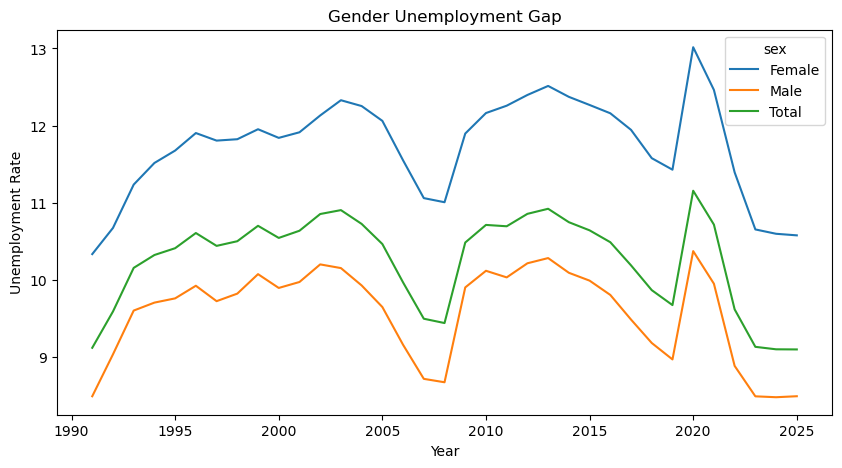

RMSE: 1.2223763972050197
R2 Score: 0.9856483328484053
       country  year  predicted
496        3.0  2005   37.83907
6019      15.0  2022   27.38059
2755       8.0  1999   20.35445
30190    152.0  1994   23.81031
51963    166.0  2017   23.44600
...        ...   ...        ...
8122      20.0  1998   34.36965
11749     26.0  2015   25.81063
18076     58.0  2012   31.93047
11227     34.0  2003   21.41498
2725       8.0  2003   20.64556

[1533 rows x 3 columns]


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

df = pd.read_csv(r"C:\Users\moham\Downloads\disoccupazione.csv")

df['obs_value'] = pd.to_numeric(df['obs_value'], errors='coerce')
df['obs_value'] = df['obs_value'].fillna(df['obs_value'].mean())

print(df.columns)

gender_gap = df.groupby(['year', 'sex'])['obs_value'].mean().unstack()

gender_gap.plot(figsize=(10,5))
plt.title("Gender Unemployment Gap")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate")
plt.show()

df = df.sort_values(by=['country', 'year'])

df['lag_1'] = df.groupby('country')['obs_value'].shift(1)

df['rolling_avg'] = df.groupby('country')['obs_value'].rolling(3).mean().reset_index(0, drop=True)

encoder = OrdinalEncoder()

df[['country', 'sex', 'age']] = encoder.fit_transform(df[['country', 'sex', 'age']])
X = df[['country', 'year', 'sex', 'age', 'lag_1', 'rolling_avg']]
y = df['obs_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

print("R2 Score:", r2_score(y_test, y_pred))
test = X_test.copy()          
test['predicted'] = y_pred        
high_risk =test[test['predicted'] > 20]

print(high_risk[['country', 'year', 'predicted']])

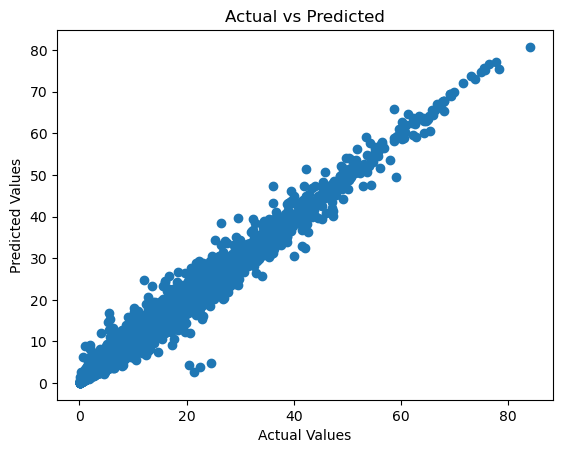

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

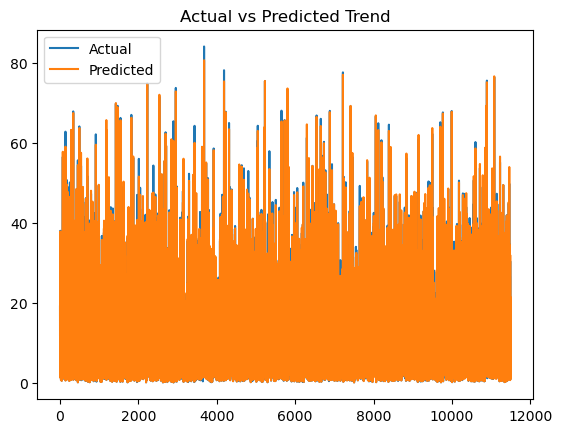

In [15]:
plt.figure()
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Trend")
plt.show()

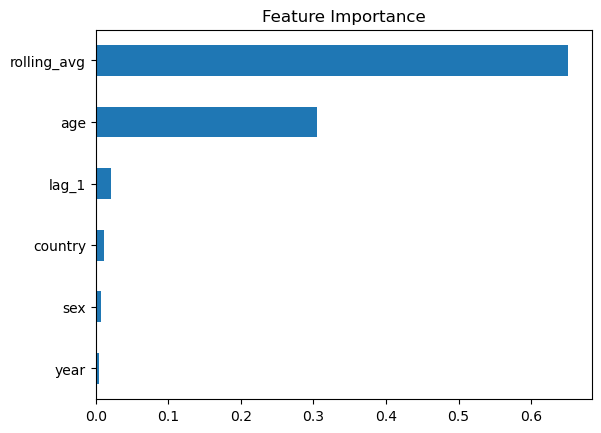

In [16]:
import pandas as pd

importance = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features)

feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

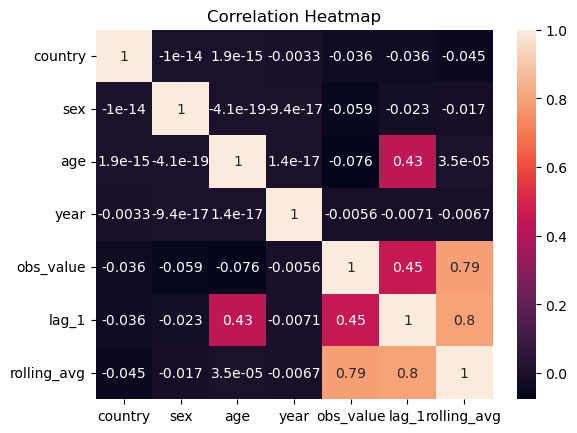

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_df = df.select_dtypes(include=['number'])
plt.figure()
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

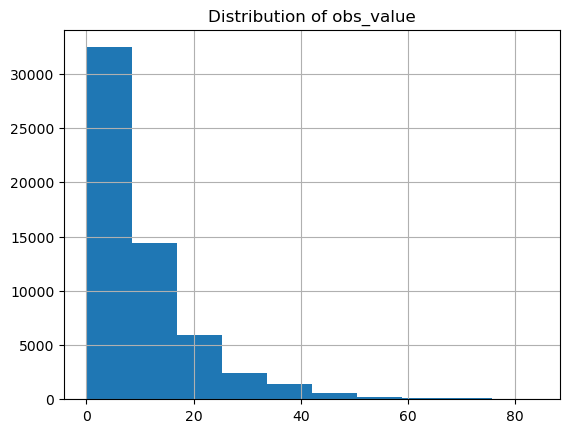

In [18]:
plt.figure()
df['obs_value'].hist()
plt.title("Distribution of obs_value")
plt.show()